In [45]:
import pandas as pd              # Para análisis de datos
import numpy as np               # Para cálculos numéricos
import matplotlib.pyplot as plt  # Para gráficos
import seaborn as sns            # Para gráficos bonitos
from scipy import fft      # Importo el subpaquete fft para Fourier Transforms (aunque SciPy es un paquete de scientific computation)

Vamos a generar una señal (con dos señales predominantes) con ruido conocida y luego vamos a utilizar la transformada de Fourier para obtener las dos señales predominantes a partir de la señal con ruido incial (proceso a la inversa).

Generamos dos señales sinusoidales y las juntamos.

In [46]:
sinfreq1 = 27 # Hz
sinfreq2 = 35 # Hz
step = 0.001

npTime = np.arange(start=0,stop=1,step=step) # Genera array de 0 a 1, sin contar el 1, con steps de 0.001
npSin1 = np.sin(2*np.pi*sinfreq1*npTime)
npSin2 = np.sin(2*np.pi*sinfreq2*npTime)
cleanSignal = npSin1 + npSin2 # clean signal

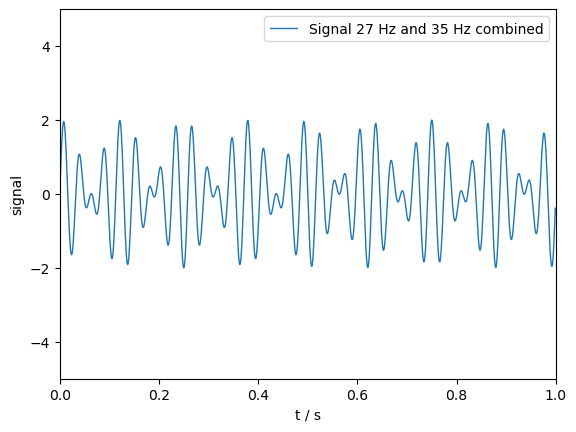

In [47]:
## Combined signal, clean
plt.plot(npTime,cleanSignal,linewidth=1,label="Signal "+str(sinfreq1)+" Hz and "+str(sinfreq2) + " Hz combined")
plt.margins(x=0, y=1)
plt.legend()
plt.xlabel('t / s')
plt.ylabel('signal')
plt.xlim(0,1)
plt.ylim(-5,5)
plt.show()

Ahora añadiremos "ruido" a la señal.

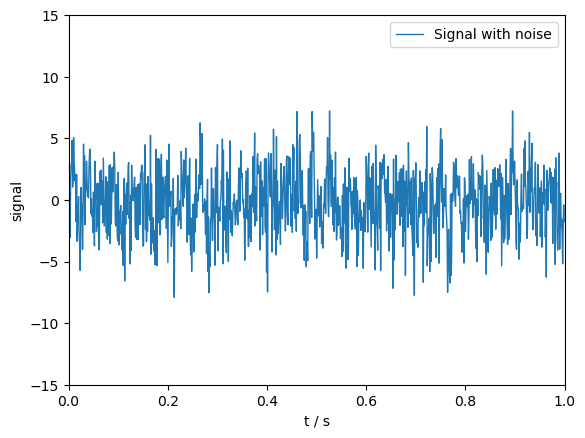

In [48]:
# Adding some random noise to the signal
noise = 2.5*np.random.randn(len(npTime)) # Generación de numeros aleatorios
noiseSignal = cleanSignal + noise

# Plot the noise signal
plt.plot(npTime,noiseSignal,linewidth=1,label="Signal with noise")
plt.margins(x=0, y=1)
plt.legend()
plt.xlabel('t / s')
plt.ylabel('signal')
plt.xlim(0,1)
plt.ylim(-15,15)
plt.show()

Ahora vamos a aplicar la DFT (discrete Fourier transform) a la señal con ruido que tenemos: $\mathcal{F}(f(t)) = \mathcal{F}(\nu)$. 

¡¡ Pasamos del régimen de tiempos al régimen de frecuencias !! 

In [49]:
F_noiseSignal = fft.rfft(noiseSignal) # DFT de la señal
absF_noiseSignal = np.abs(F_noiseSignal) # Valores absolutos de la DFT
n = len(noiseSignal)
npFrequency = fft.rfftfreq(n,step) # Valores de frecuencia asociados a esa DFT

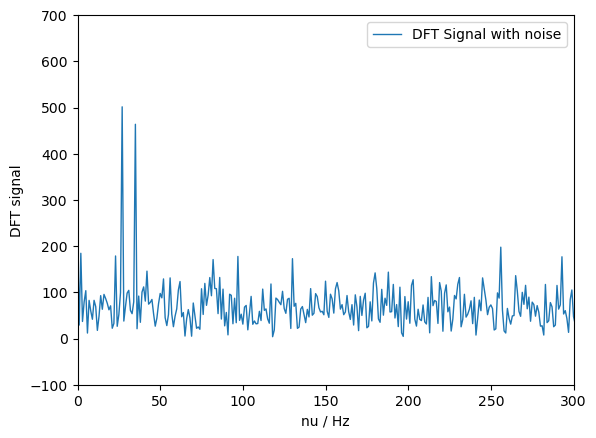

In [54]:
# Plot the noise signal
plt.plot(npFrequency,absF_noiseSignal,linewidth=1,label="DFT Signal with noise")
plt.margins(x=0, y=1)
plt.legend()
plt.xlabel('nu / Hz')
plt.ylabel('DFT signal')
plt.xlim(0,300)
plt.ylim(-100,700)
plt.show()

Aquí claramente vemos dos picos claramente diferenciados (dos picos de frecuencias). Así que ahora podemos filtrar el ruido de fondo.

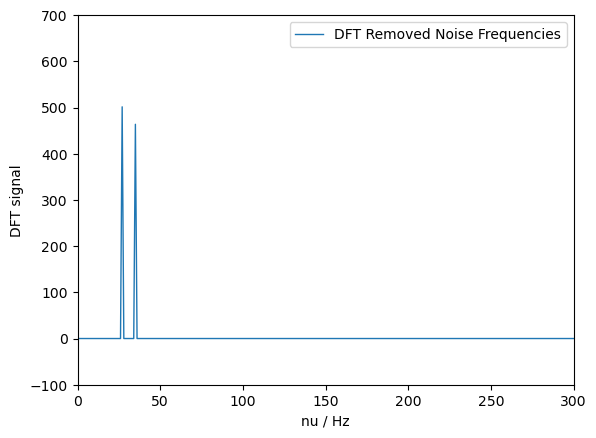

In [53]:
indices = absF_noiseSignal > 300   # filter out those value under 300 (Array booleano)
F_Clean    = indices * F_noiseSignal 
# noise frequency will be set to 0 (al multiplicar array booleano por array numerico, True -> 1 y False -> 0)
plt.plot(npFrequency,np.abs(F_Clean),linewidth=1,label="DFT Removed Noise Frequencies")
plt.margins(x=0, y=0.5)
plt.legend()
plt.xlabel('nu / Hz')
plt.ylabel('DFT signal')
plt.xlim(0,300)
plt.ylim(-100,700)
plt.show()

Ahora hacemos $\mathcal{F}^{-1}(\mathcal{F}(\nu)) = f(t)$ para recuperar la señal inicial.

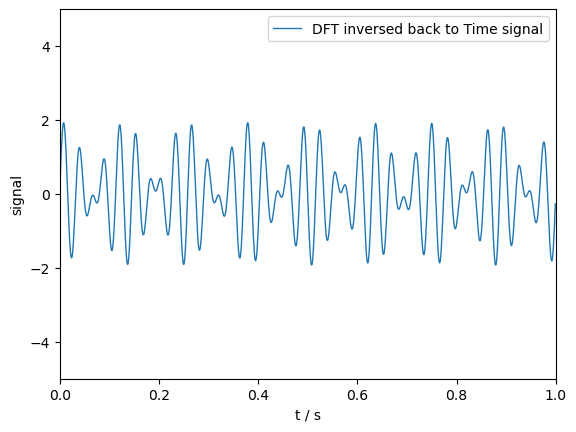

In [52]:
newFClean = fft.irfft(F_Clean)
plt.plot(npTime,newFClean,linewidth=1,label="DFT inversed back to Time signal")
plt.margins(x=0, y=1)
plt.legend()
plt.xlabel('t / s')
plt.ylabel('signal')
plt.xlim(0,1)
plt.ylim(-5,5)
plt.show()

Aún se podrían obtener las señales monofrecuencia si quisiéramos...